## How many senses does the cell have? 

Goal: Take mutagenesis data and construct a mapping so that if expression levels of various genes are known, environment can be recovered. 

Approach 1: Apply PCA to a matrix containing expression data for clusters of cells from different environments. 

Appraoch 2: Look at natural variation, where high variation at a binding site indicates that that binding site is not in use. 

Approach 3: Bayesian Inference.

Starting with "Approach 1." First, construct a matrix to perform PCA on. Say there are $m$ different genes and $n$ different conditions. Specify a batch count, $\nu$, which is the number of batches the sequence collection will be divided into, for each environment. This matrix will have $\nu n$ rows and $m$ columns. The entries will be expression data for 

In [164]:
import os
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random

import equinox as eqx

from promdis.processing import get_sequence_arrays_and_counts, gene_seq_to_array
from promdis.jax.core import compute_mean_expression_shift
from promdis.jax.core import compute_expression_shift_by_mutation
from promdis.jax.core import compute_expression_shift_by_pairwise_mutation
from promdis.jax.core import compare_sequences
from promdis.pl import plot_data_2d


In [165]:
#Specify a bactch count
nu = 100
size = 100

In [166]:

OUTDIR = "../results/epistasis"
os.makedirs(OUTDIR, exist_ok=True)

SEED = None
rng = np.random.default_rng(seed=SEED)

with open('../data/gene_list.txt', 'r') as file:
    # Read lines into a list
    genes = file.readlines()
    
with open('../data/condition_list.txt', 'r') as file:
    # Read lines into a list
    conditions = file.readlines()
    


In [167]:
data = np.zeros((nu*len(conditions), len(genes)))


for COND in conditions:
    for GENE in genes:
        GENE0 = GENE.replace('\n', '')
        COND0 = COND.replace('\n','')
        
        FPATH = f"../data/regseq_data/{GENE0}{COND0}dataset_alldone_with_large"
        
        # Check if the file exists
        if not os.path.exists(FPATH):
            print(f"File not found: {FPATH}")
            continue


        df = pd.read_csv(FPATH, sep='\\s+')
        df['barcode'] = df['seq'].str.slice(160,)
        df['promoter'] = df['seq'].str.slice(0, 160)

        seqs, counts_dna, counts_rna = get_sequence_arrays_and_counts(
            df, key_promoter='promoter', key_rna='ct_1', key_dna='ct_0'
        )

        expression = counts_rna / (counts_dna + counts_rna)
        
        subset_arr = np.zeros(nu)
        for k in range(nu):
            # sample = random.sample(range(len(expression)), size)
            sample = rng.choice(len(expression), size, replace=True)
            selected_exp = [expression[i] for i in sample]
            data[k + nu*conditions.index(COND)][genes.index(GENE)] = np.sum(selected_exp) / len(selected_exp)

    #Mean centering each condition: 
    data[nu*conditions.index(COND): nu + nu*conditions.index(COND)] = data[nu*conditions.index(COND): nu + nu*conditions.index(COND)] - np.mean(data[nu*conditions.index(COND): nu + nu*conditions.index(COND)])
        
            
            



File not found: ../data/regseq_data/yagH0cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/eco0cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/yagH500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/eco500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/ycgB500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/ydhO500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/ymgG500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/ygeR500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/yggW500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/mscL500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/dpiBA500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/adiY500cAMPdataset_alldone_with_large
File not found: ../data/regseq_data/ecoTredataset_alldone_with_large


In [168]:

##data = data[:,0:10] pick 10 genes

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


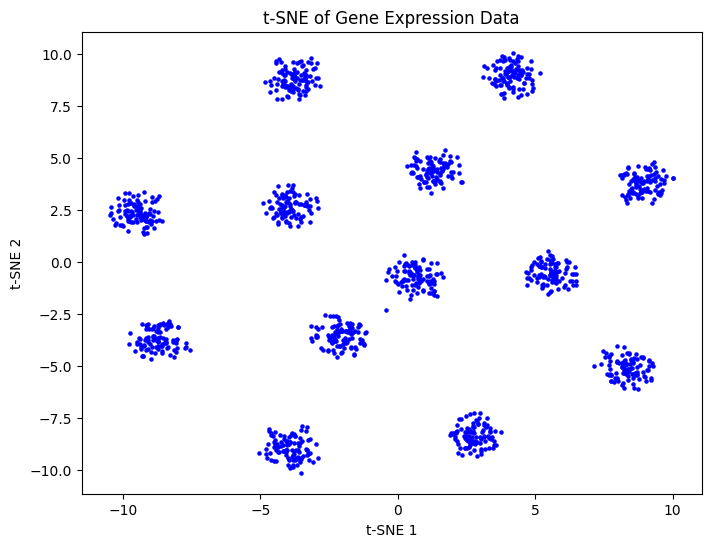

In [169]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
tsne_results = tsne.fit_transform(data)

tsne_df = pd.DataFrame(data=tsne_results, columns=['t-SNE1', 't-SNE2'])

plt.figure(figsize=(8, 6))
plt.scatter(tsne_df['t-SNE1'], tsne_df['t-SNE2'], color = 'blue', s = 5)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE of Gene Expression Data')
plt.show()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


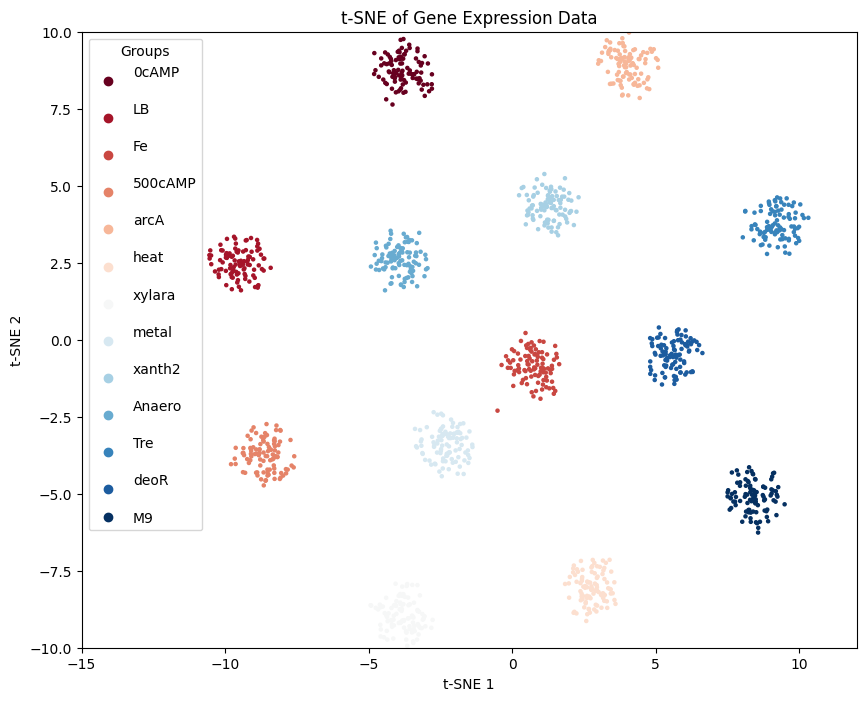

In [170]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np



num_cells = data.shape[0]
num_groups = num_cells // nu


group_labels = np.repeat(range(num_groups), nu)


tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
tsne_results = tsne.fit_transform(data)


tsne_df = pd.DataFrame(data=tsne_results, columns=['t-SNE1', 't-SNE2'])
tsne_df['Group'] = group_labels


plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_df['t-SNE1'], tsne_df['t-SNE2'], c=tsne_df['Group'], cmap='RdBu', s = 5)

handles, _ = scatter.legend_elements()
legend_labels = [conditions[i] for i in range(num_groups)]
plt.legend(handles, legend_labels, title="Groups")

plt.xlim(-15, 12)
plt.ylim(-10, 10)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE of Gene Expression Data')
plt.show()

[[ 0.05639162  0.09727771 -0.08169774  0.17258536 -0.02753834  0.122957
  -0.14148698  0.16790616  0.07005717 -0.04412902 -0.05449299 -0.00409025
  -0.0956408  -0.04473413 -0.01407092 -0.07893275 -0.07985892 -0.07988398
  -0.01605809 -0.11152016 -0.0139904  -0.20592308 -0.12550612 -0.17193011
  -0.23289234 -0.06601778  0.22413229 -0.06741317 -0.06240733 -0.02646148
  -0.00342322 -0.02581037 -0.06051703 -0.09764585 -0.12217265 -0.13464005
  -0.06008458 -0.12292922  0.07001034  0.04135331 -0.07816454 -0.03248359
  -0.04903069 -0.02001641 -0.11576791 -0.01664767 -0.07060297 -0.02210007
   0.05232157  0.00072639  0.02702055  0.06316085  0.05829438  0.00977084
  -0.04378179 -0.03287499  0.01465491  0.08114501  0.33287255  0.11835853
   0.02441629 -0.00047488  0.18870936 -0.00278161  0.00584631 -0.09435377
  -0.15605587 -0.0474653   0.20819543 -0.0526396   0.19016344  0.08322922
   0.04651941  0.05576298 -0.07537473  0.03366114 -0.02134041 -0.03400213
  -0.01344881  0.01049079 -0.037698    0

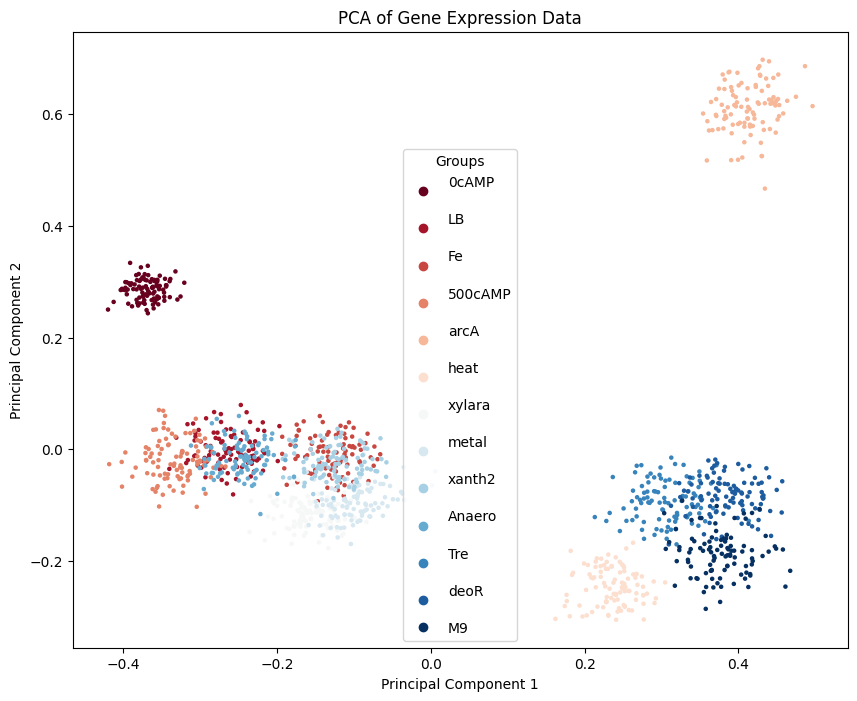

In [171]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np



num_cells = data.shape[0]
num_groups = num_cells // nu


group_labels = np.repeat(range(num_groups), nu)


pca = PCA(n_components=2)  
principal_components = pca.fit_transform(data)

print(pca.components_)


pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Group'] = group_labels





plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Group'], cmap='RdBu', s = 5)

handles, _ = scatter.legend_elements()
legend_labels = [conditions[i] for i in range(num_groups)]
plt.legend(handles, legend_labels, title="Groups")

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Gene Expression Data')
plt.show()


[[ 0.05639162  0.09727771 -0.08169774  0.17258536 -0.02753834  0.122957
  -0.14148698  0.16790616  0.07005717 -0.04412902 -0.05449299 -0.00409025
  -0.0956408  -0.04473413 -0.01407092 -0.07893275 -0.07985892 -0.07988398
  -0.01605809 -0.11152016 -0.0139904  -0.20592308 -0.12550612 -0.17193011
  -0.23289234 -0.06601778  0.22413229 -0.06741317 -0.06240733 -0.02646148
  -0.00342322 -0.02581037 -0.06051703 -0.09764585 -0.12217265 -0.13464005
  -0.06008458 -0.12292922  0.07001034  0.04135331 -0.07816454 -0.03248359
  -0.04903069 -0.02001641 -0.11576791 -0.01664767 -0.07060297 -0.02210007
   0.05232157  0.00072639  0.02702055  0.06316085  0.05829438  0.00977084
  -0.04378179 -0.03287499  0.01465491  0.08114501  0.33287255  0.11835853
   0.02441629 -0.00047488  0.18870936 -0.00278161  0.00584631 -0.09435377
  -0.15605587 -0.0474653   0.20819543 -0.0526396   0.19016344  0.08322922
   0.04651941  0.05576298 -0.07537473  0.03366114 -0.02134041 -0.03400213
  -0.01344881  0.01049079 -0.037698    0

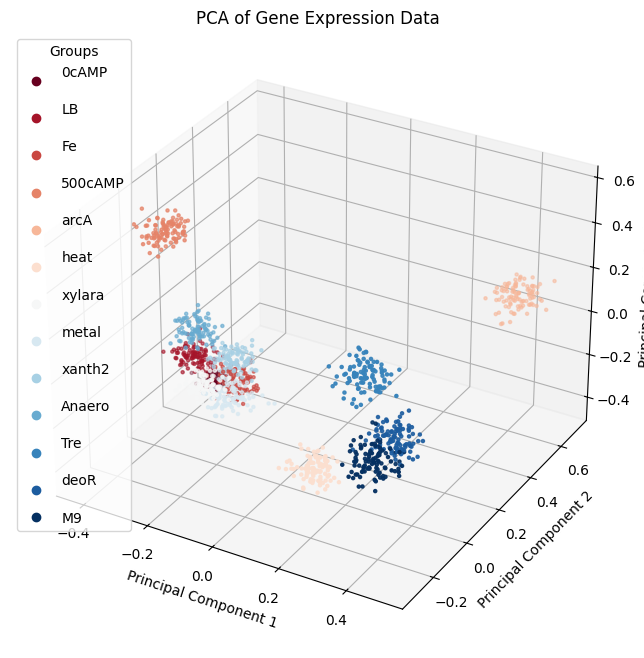

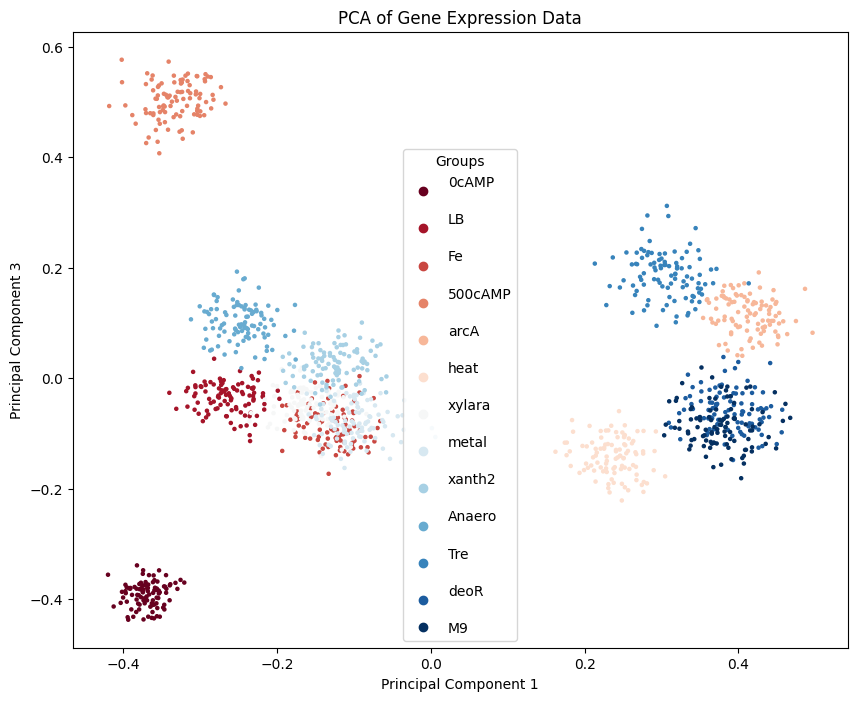

In [194]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


# Assuming data is your gene expression matrix DataFrame
num_cells = data.shape[0]
num_groups = num_cells // nu

# Create group labels
group_labels = np.repeat(range(num_groups), nu)

# Perform PCA
pca = PCA(n_components=3)  # Reduce to 3 dimensions for visualization
principal_components = pca.fit_transform(data)

print(pca.components_)

# Create a DataFrame with the principal components and group labels
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])
pca_df['Group'] = group_labels

# Plot the principal components with colors corresponding to groups
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c=pca_df['Group'], cmap='RdBu', s=5)

# Create a legend with the group names
handles, _ = scatter.legend_elements()
legend_labels = [conditions[i] for i in range(num_groups)]
plt.legend(handles, legend_labels, title="Groups")


ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('PCA of Gene Expression Data')

plt.show()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC3'], c=pca_df['Group'], cmap='RdBu', s = 5)

handles, _ = scatter.legend_elements()
legend_labels = [conditions[i] for i in range(num_groups)]
plt.legend(handles, legend_labels, title="Groups")

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 3')
plt.title('PCA of Gene Expression Data')
plt.show()


In [195]:
pca_1_sqr = pca.components_[0]**2
pca_2_sqr = pca.components_[1]**2
pca_3_sqr = pca.components_[2]**2

pca1_arg = np.argsort(pca_1_sqr)
pca2_arg = np.argsort(pca_2_sqr)
pca3_arg = np.argsort(pca_3_sqr)

indices = np.concatenate([pca1_arg[-10:], pca2_arg[-3:], pca3_arg[-2:]])

[[-0.181236    0.20544621  0.29737173  0.23949065 -0.23796188  0.24581599
   0.27566096 -0.26882127  0.34233207  0.51113919  0.1180652   0.23037052
   0.09627606 -0.02701913 -0.241642  ]
 [ 0.17147251 -0.17131332  0.28260279 -0.06271226  0.08481597 -0.14720378
  -0.2883083   0.14167011 -0.2028327   0.15635737  0.39988533  0.46062413
   0.45896522 -0.21443038  0.17634029]
 [ 0.25857805 -0.23857956 -0.14298081 -0.11481423  0.40287868 -0.22368154
   0.04625554  0.13541597  0.34906328  0.25717139  0.06796213 -0.03007544
   0.14480161  0.51179073 -0.36519407]]


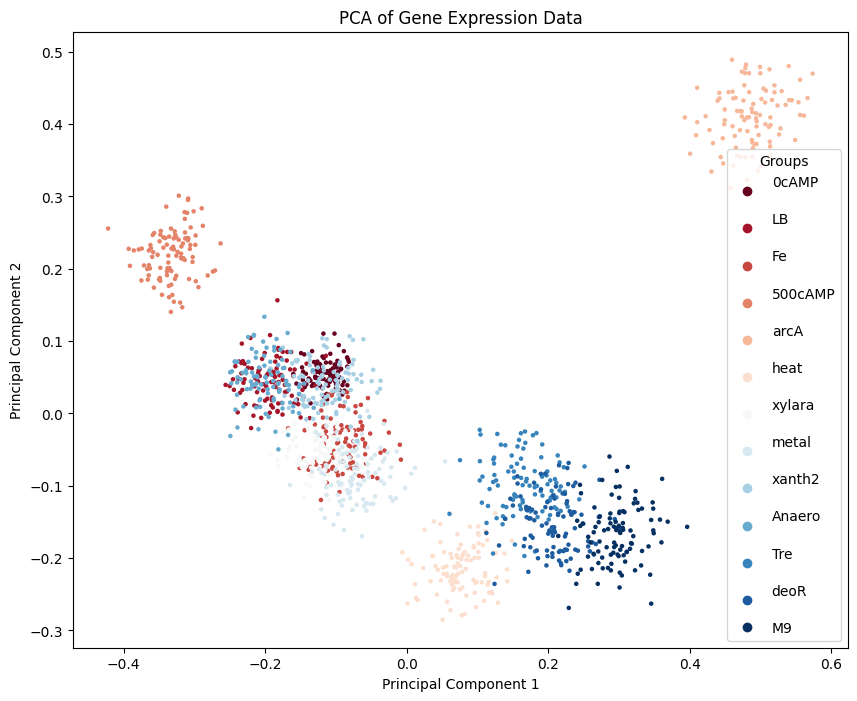

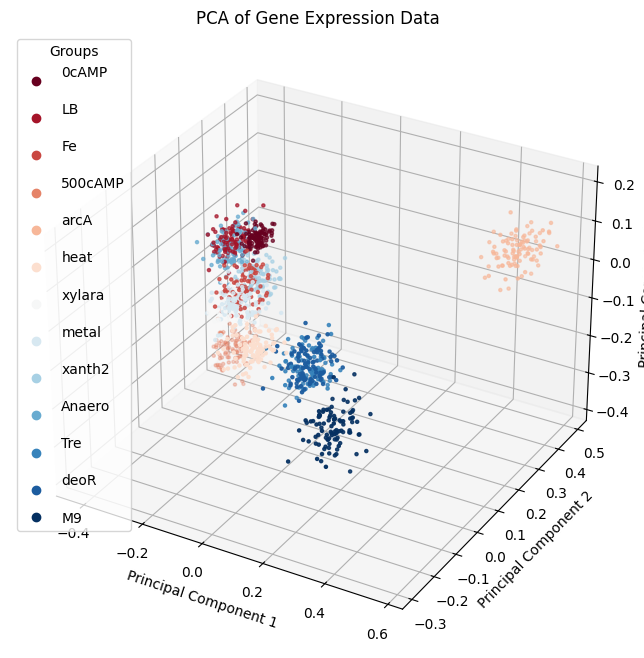

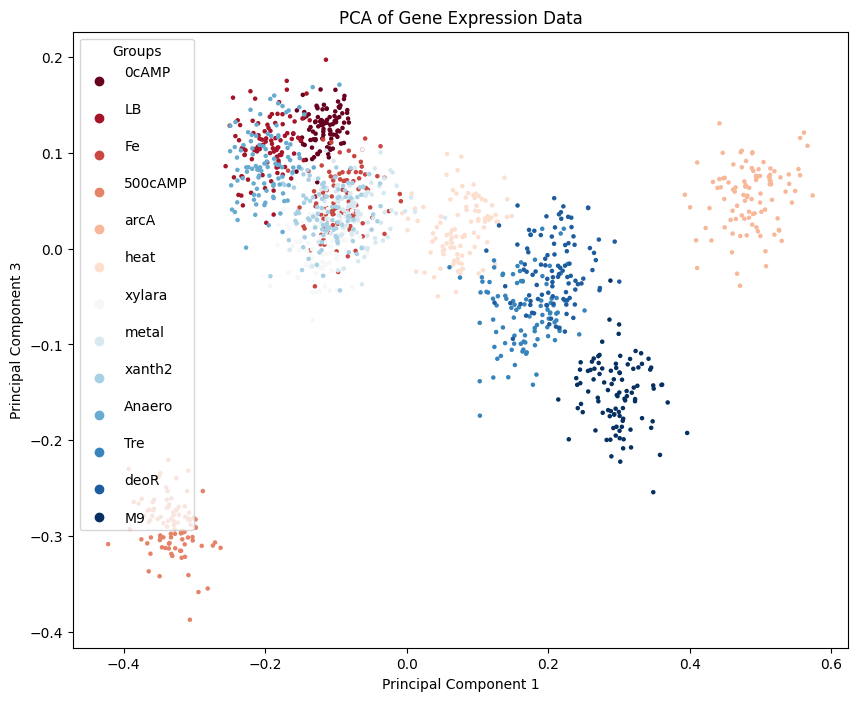

In [196]:


#indices = pca1_arg[-10:]

data_best_genes = data[:,indices] 


num_cells = data.shape[0]
num_groups = num_cells // nu


group_labels = np.repeat(range(num_groups), nu)


pca = PCA(n_components=3)  
principal_components = pca.fit_transform(data_best_genes)

print(pca.components_)


pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])
pca_df['Group'] = group_labels


plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Group'], cmap='RdBu', s = 5)

handles, _ = scatter.legend_elements()
legend_labels = [conditions[i] for i in range(num_groups)]
plt.legend(handles, legend_labels, title="Groups")

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Gene Expression Data')
plt.show()

# Plot the principal components with colors corresponding to groups
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'], c=pca_df['Group'], cmap='RdBu', s=5)

# Create a legend with the group names
handles, _ = scatter.legend_elements()
legend_labels = [conditions[i] for i in range(num_groups)]
plt.legend(handles, legend_labels, title="Groups")


ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('PCA of Gene Expression Data')

plt.show()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC3'], c=pca_df['Group'], cmap='RdBu', s = 5)

handles, _ = scatter.legend_elements()
legend_labels = [conditions[i] for i in range(num_groups)]
plt.legend(handles, legend_labels, title="Groups")

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 3')
plt.title('PCA of Gene Expression Data')
plt.show()


            